# a04 Example - Bayesian Optimization using AX Client on Townsend Function

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install ax-platform

# Imports

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

from ax.api.client import Client
from ax.api.configs import RangeParameterConfig

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Townsend function to optimize.
    """
    return -np.cos((v1 - 0.1) * v2) ** 2 - v1 * np.sin(3 * v1 + v2)

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt, x0, xf, y0, yf):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
    ax.set_xlim([x0, xf])
    ax.set_ylim([y0, yf])
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                cmap='viridis')
    ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `AXOptimizeScan`

In [6]:
class AXOptimizeScan(ps.AbstractOptimizeScan):
    """
    AX API
    """


    def __init__(self, initialization_dict, prop, optimizer_inputs, sample_function_output,
                 bounds_list,
                 dt=0., n_max=100,
                 global_improvement_threshold=1e-2,
                 global_improvement_index_window=10,
                 global_improvement_start_index=10,
                 extremum='min'):
        
        super().__init__(initialization_dict, prop, optimizer_inputs, sample_function_output,
                         dt=dt, n_max=n_max)

        self.last_optim_idx = n_max - 1 # stop optimizing on second-to-last index so that last index is best discovered value
        self.gi_t = global_improvement_threshold
        self.gi_i_w = global_improvement_index_window
        self.gi_st_i = global_improvement_start_index
        self.extremum = extremum
        parameters = [
            RangeParameterConfig(name=self.opt_in[i], parameter_type="float", bounds=bounds_list[i])
            for i in range(len(self.opt_in))
        ]
        self.client = Client()
        self.client.configure_experiment(parameters=parameters)
        match extremum:
            case 'max':
                self.objective = f"{self.sample_f_out}"
            case 'min':
                self.objective = f"-{self.sample_f_out}"
            case _:
                raise ValueError('Extremum must be max or min')
        self.client.configure_optimization(objective=self.objective)

        self.proposed_trial_index = None
        self.gi_latest_i = None

    def step_optimizer(self, index, experiment):
            
            def early_stop(f_out, f_out_best, index):
                es = False
                gi_d = f_out - f_out_best
                if self.extremum == 'min':
                    gi_d *= -1
                delta_over_threshold = gi_d > self.gi_t
                if delta_over_threshold:
                    self.gi_latest_i = index
                if self.gi_latest_i != None:
                    gi_i_d = index - self.gi_latest_i
                    index_delta_out_window = gi_i_d >= self.gi_i_w
                    stop_checking_started = index >= self.gi_st_i
                    es = index_delta_out_window and stop_checking_started
                return es

            if index == 1: # load initial point into AX measurement history
                parameters = {
                    measurement: experiment.__dict__[measurement][0]
                    for measurement in self.opt_in
                }
                prev_trial_index = self.client.attach_trial(parameters=parameters)
                f_out = experiment.__dict__[self.sample_f_out][index - 1]
                raw_data = {self.sample_f_out: f_out}
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)
            else: # load last proposed trial results into AX measurement history
                best_parameters, best_prediction, best_index, best_name = self.client.get_best_parameterization(use_model_predictions=False)
                f_out = experiment.__dict__[self.sample_f_out][index - 1]
                raw_data = {self.sample_f_out: f_out}
                prev_trial_index = self.proposed_trial_index
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)

                f_out_best = best_prediction[self.sample_f_out][0] # get mean from (mean, sem) of output
                if index >= self.last_optim_idx or early_stop(f_out, f_out_best, index):
                    f_in_next = [
                            best_parameters[measurement]
                            for measurement in self.opt_in
                        ]
                    self.running = False
                    print(f"best param: {best_parameters}")
                    return f_in_next

            trials = self.client.get_next_trials(max_trials=1) # only 1 trial
            for trial_index, parameters in trials.items(): # only 1 item
                f_in_next = [
                    parameters[measurement]
                    for measurement in self.opt_in
                ]
                self.proposed_trial_index = trial_index

            return f_in_next


# Instantiate OptimizeScan

In [7]:
x0 = -2.5
xf = 2.5
y0 = -1.5
yf = 1.5

In [8]:
runinfo.scan0 = AXOptimizeScan({'v1': 0., 'v2': 0.}, 'voltage', ('v1_readout', 'v2_readout'), 'vf',
                               ((x0, xf), (y0, yf)),
                               dt=1., n_max=100,
                               global_improvement_threshold=1e-2,
                               global_improvement_index_window=10,
                               global_improvement_start_index=40,
                               extremum='max')

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

[INFO 01-05 15:22:35] ax.api.client: Trial 0 marked COMPLETED.
[INFO 01-05 15:22:35] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(node_name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(node_name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[WARNING 01-05 15:22:35] ax.generation_strategy.generation_node: gen failed with error GenerationStrategy exceeded `MAX_GEN_ATTEMPTS` of 5 while trying to generate a unique parameterization. This indicates that the search space has likely been fully explored, or that the sweep has converged., switching to fallback model with generator_enum Generators.SOBOL
[INFO 01-05 15:22:35] ax.api.client: Generated n

best param: {'v1_readout': 1.9219260290968652, 'v2_readout': -0.8978797230651077}
Stopping Experiment


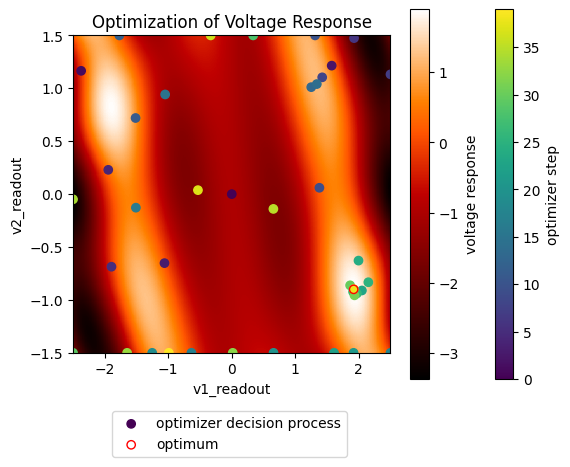

In [10]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt, x0, xf, y0, yf)
except KeyboardInterrupt:
    expt.stop()

In [11]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x136eeedc8c0>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x136eef022a0>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 19572)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40.]),
 'v1_readout': array([ 0.        , -2.37259904,  1.57416672, -1.05964597, -1.94536147,
        -1.89483594,  1.92606328,  2.5       ,  1.42454069,  1.38035122,
         1.31270103, -1.51503151, -1.77081066,  1.25183467,  1.33980144,
        -1.04905024, -1.51012418, -0.63539781,  2.5       , -1.25320404,
         0.65821686,  1.91884761,  1.61110827,  2.04976847,  1.9963559 ,
         2.15132615,  1.97124489,  1.91046577,  0.33686576, -2.5       ,
         1.86415553,  1.93321104,  0.01564033, -1.648274  , -2.5       ,
         0.65555

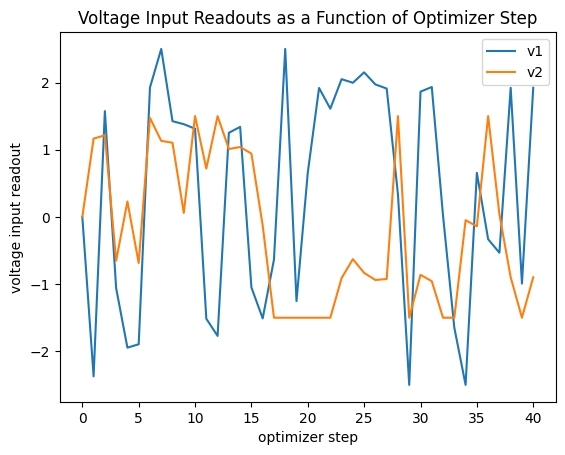

In [12]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

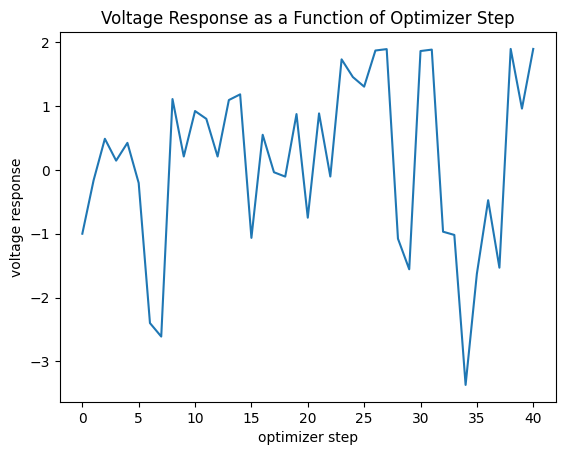

In [13]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [14]:
def plot_optim_pcm(x0, xf, y0, yf):
    fig, ax = plt.subplots()
    x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
    ax.set_xlim([x0, xf])
    ax.set_ylim([y0, yf])
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

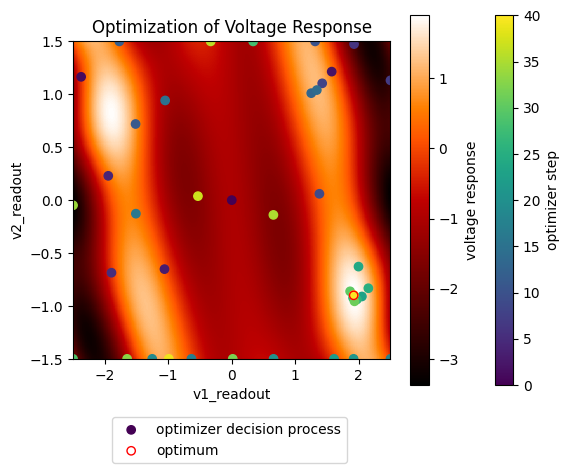

In [15]:
plot_optim_pcm(x0, xf, y0, yf)